## IMPORT DATA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

#Load data
train = pd.read_csv("train.csv")
store = pd.read_csv("store.csv")

#Overview
print("Train shape:", train.shape)
print("Store shape:", store.shape)
print("\n")
print(train.head())


/var/folders/gz/lr86w2jx4w17hxfzpbyygm4r0000gn/T/ipykernel_1573/2715221196.py:5: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


Train shape: (1017209, 9)
Store shape: (1115, 10)


   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  


## CHECK MISSING

In [3]:
# Check missing values & data types
print("=== TRAIN INFO ===")
print(train.isnull().sum())
print("\n=== STORE INFO ===")
print(store.isnull().sum())

=== TRAIN INFO ===
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

=== STORE INFO ===
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


## CLEAN DATA

In [4]:
# Bỏ ngày store đóng cửa (Sales = 0)
train_open = train[train["Open"] == 1]

print("Rows sau khi filter:", train_open.shape[0])
print("\nSales summary:")
print(train_open["Sales"].describe())

Rows sau khi filter: 844392

Sales summary:
count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64


## SALES THEO THOI GIAN

/var/folders/gz/lr86w2jx4w17hxfzpbyygm4r0000gn/T/ipykernel_1573/3827922832.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_open["Date"] = pd.to_datetime(train_open["Date"])


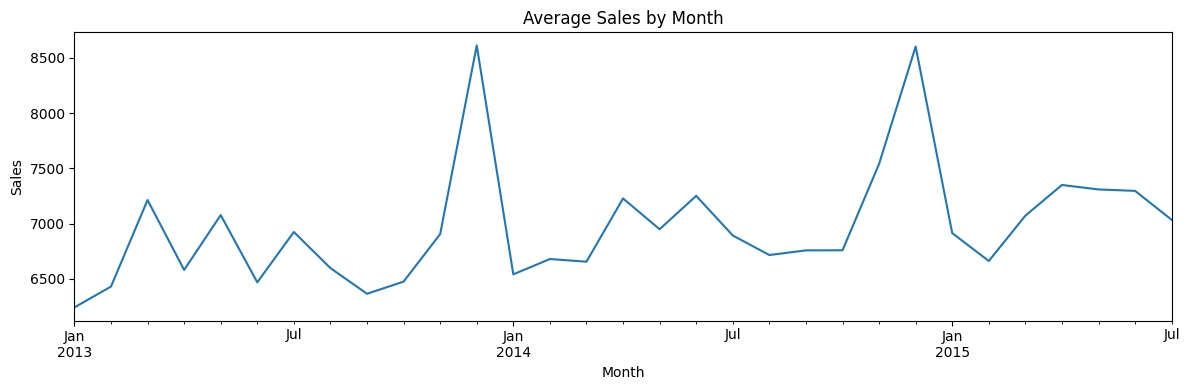

In [5]:
# Convert Date sang datetime
train_open["Date"] = pd.to_datetime(train_open["Date"])

# Sales trung bình theo tháng
monthly_sales = train_open.groupby(train_open["Date"].dt.to_period("M"))["Sales"].mean()

monthly_sales.plot(figsize=(12,4), title="Average Sales by Month")
plt.ylabel("Sales")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

## PROMO VS NO PROMO

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64


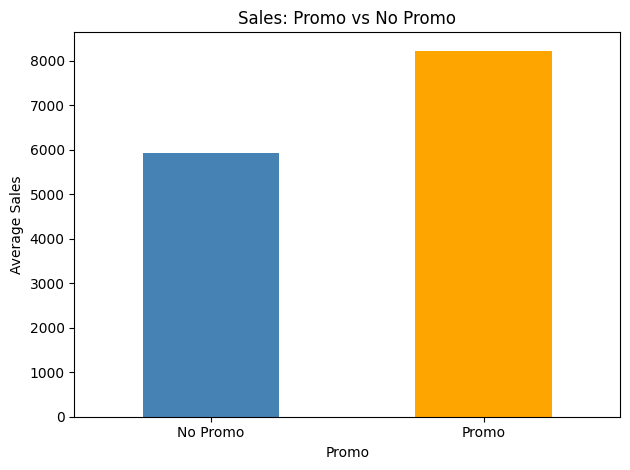

In [6]:
# So sánh Sales khi có Promo vs không có Promo
promo_sales = train_open.groupby("Promo")["Sales"].mean()
print(promo_sales)

promo_sales.plot(kind="bar", title="Sales: Promo vs No Promo", 
                 color=["steelblue", "orange"])
plt.ylabel("Average Sales")
plt.xticks([0,1], ["No Promo", "Promo"], rotation=0)
plt.tight_layout()
plt.show()

## SALES THEO DAYS OF WEEK

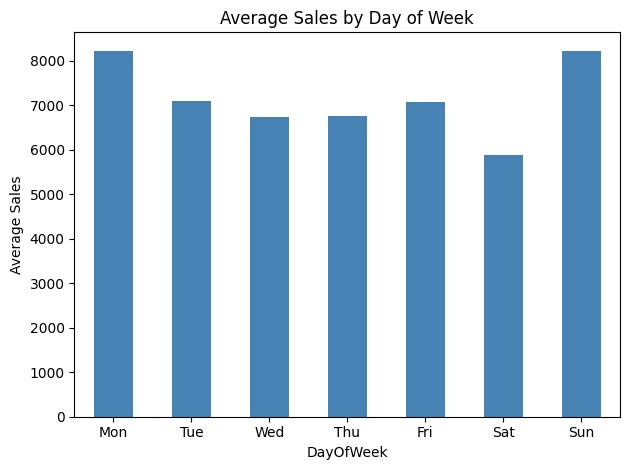

In [7]:
# Sales theo DayOfWeek
dow_sales = train_open.groupby("DayOfWeek")["Sales"].mean()

dow_sales.plot(kind="bar", title="Average Sales by Day of Week",
               color="steelblue")
plt.ylabel("Average Sales")
plt.xticks([0,1,2,3,4,5,6], 
           ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], rotation=0)
plt.tight_layout()
plt.show()